# Exploratory Data Analysis

Four things I want to check:
1. How did the four stocks actually perform over the period?
2. What do the return distributions look like?
3. How correlated are these stocks with each other?
4. Is there any visible relationship between the Google Trends data and stock returns?

## 1. Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TICKER_LABELS = {
    'MC.PA'   : 'LVMH',
    'ITX.MC'  : 'Inditex',
    'HM-B.ST' : 'H&M',
    'TPR'     : 'Tapestry',
}

prices = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
trends = pd.read_csv('data/trends.csv', index_col=0, parse_dates=True)
macro  = pd.read_csv('data/macro.csv',  index_col=0, parse_dates=True)
prices.columns = [TICKER_LABELS.get(c, c) for c in prices.columns]

print('Prices:', prices.shape)
print('Trends', trends.shape)
print('Macro:', macro.shape)

Prices : (1550, 4)
Trends : (72, 3)
Macro  : (72, 2)


## 2. Stock Price Performance

Raw prices aren't directly comparable because the stocks trade in different currencies and at very different price levels. Normalizing everything to 100 at the start of the period puts them on the same scale so 120 means "up 20% from the start", regardless of the currency.

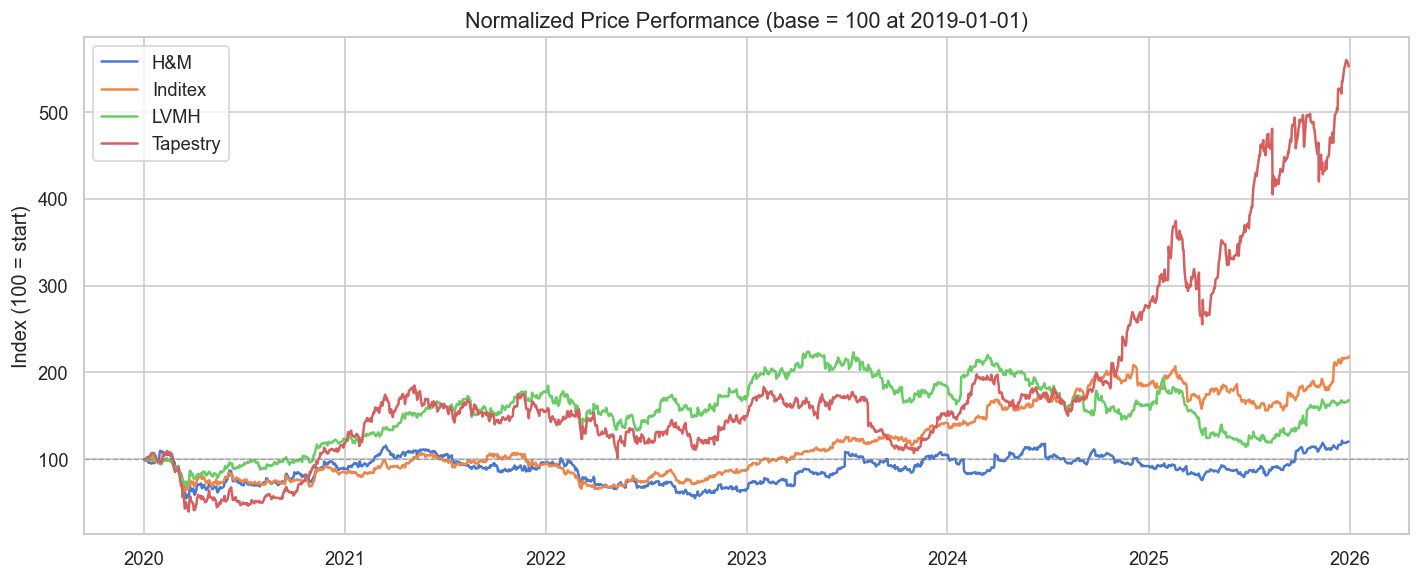

In [ ]:
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))

for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

ax.axhline(100, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_title('Normalized Price Performance (base = 100 at 2019-01-01)', fontsize=13)
ax.set_ylabel('Index (100 = start)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Daily Log Returns

Log returns are better than simple percentage returns for financial analysis. They're additive over time and more symmetric, which makes them better-behaved mathematically. The formula is just $r_t = \ln(P_t / P_{t-1})$.

I'm plotting the distribution of each stock's returns to see how fat the tails are and whether there are obvious outliers.

In [ ]:
log_returns = np.log(prices / prices.shift(1)).dropna()

stats = log_returns.describe().T
stats['skew']     = log_returns.skew()
stats['kurtosis'] = log_returns.kurt()
stats['ann_vol']  = log_returns.std() * np.sqrt(252)
print(stats[['mean', 'std', 'min', 'max', 'skew', 'kurtosis', 'ann_vol']].round(4))

            mean     std     min     max    skew  kurtosis  ann_vol
H&M       0.0001  0.0228 -0.1389  0.1670  0.1829    8.9504   0.3620
Inditex   0.0005  0.0177 -0.1113  0.1313  0.2447    5.8002   0.2815
LVMH      0.0003  0.0190 -0.0908  0.1206  0.3492    4.4117   0.3014
Tapestry  0.0011  0.0311 -0.3463  0.2599 -0.8629   17.2196   0.4938


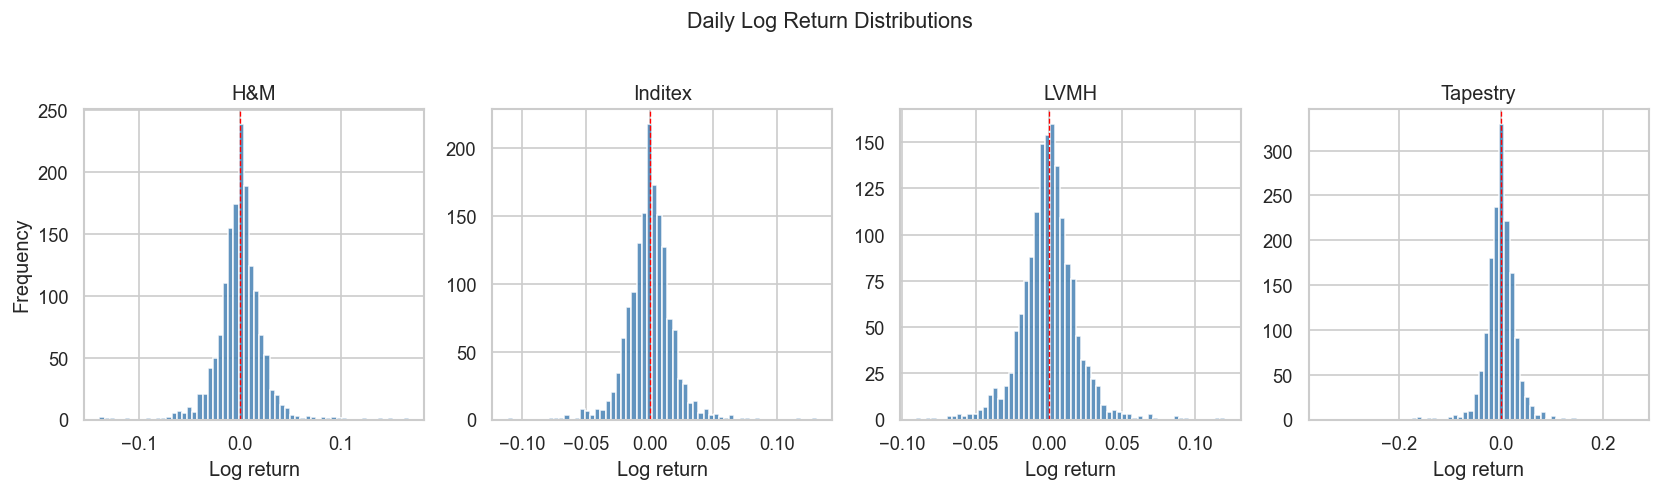

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

for ax, col in zip(axes, log_returns.columns):
    ax.hist(log_returns[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('Log return')

axes[0].set_ylabel('Frequency')
fig.suptitle('Daily Log Return Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlation Between Stocks

Portfolio diversification only works if the stocks don't move perfectly together. If everything goes up and down at the same time, holding four stocks isn't better than holding one. The correlation matrix shows how much each pair of stocks moves in sync.

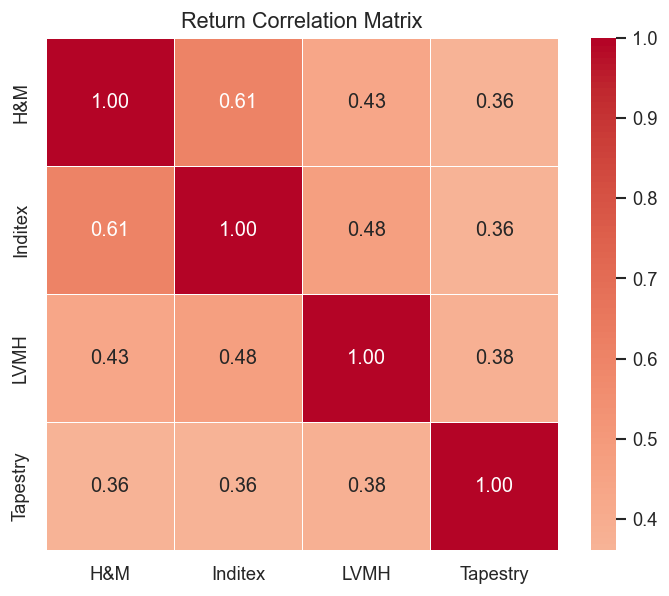

In [ ]:
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Return Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Google Trends Timeline

This is the part I was most curious about. The three keywords track different ends of the fashion market -"quiet luxury" is aspirational and high-end, "streetwear" is mass-market, "zara haul" is basically a direct signal for Inditex. Plotting them together should show whether the trends move independently or whether they're driven by the same underlying consumer mood.

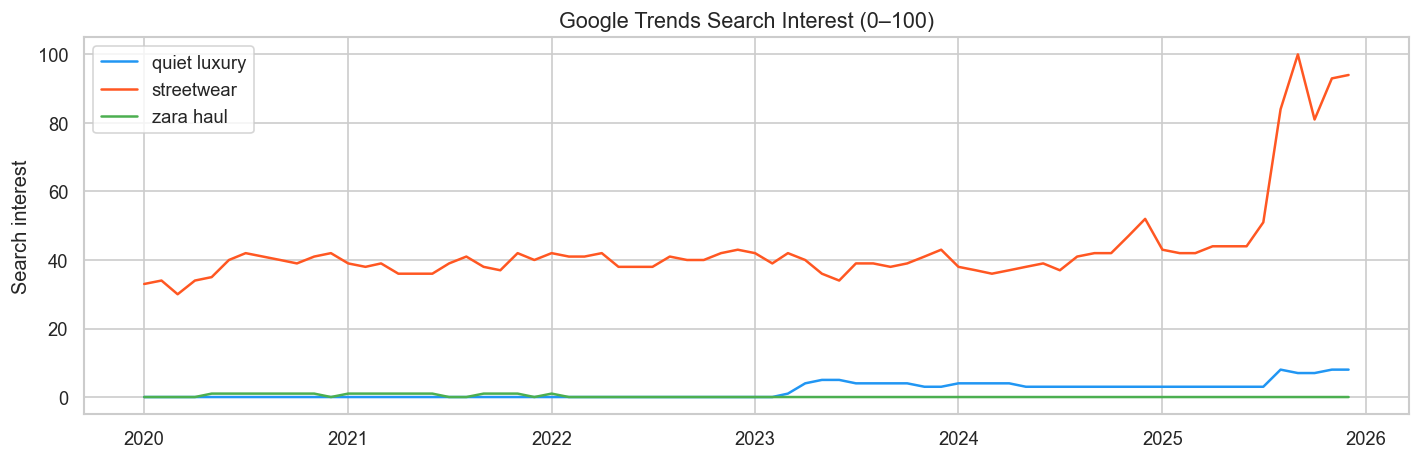

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = ['#2196F3', '#FF5722', '#4CAF50']
for col, color in zip(trends.columns, colors):
    ax.plot(trends.index, trends[col], label=col, linewidth=1.5, color=color)

ax.set_title('Google Trends Search Interest (0–100)', fontsize=13)
ax.set_ylabel('Search interest')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()